# This notebook compares the tcrbridge perdictions of the tumor samples

figures 5, S5

### set parameters

In [ ]:
import matplotlib as mpl
import matplotlib.font_manager as fm
def set_mpl_params(mpl): 
    mylines = 0.75 # pt updated
    mpl.rcParams['axes.linewidth'] = mylines # default 1
    mpl.rcParams['ytick.direction'] = 'out' # default 'in'
    mpl.rcParams['xtick.direction'] = 'out' # default 'in'
    mpl.rcParams['xtick.major.size'] = 3.5 # default 4
    mpl.rcParams['ytick.major.size'] = 3.5 # default 4
    mpl.rcParams['xtick.major.width'] = mylines # default 0.5
    mpl.rcParams['ytick.major.width'] = mylines # default 0.5
    mpl.rcParams['grid.linewidth'] = mylines/1.5# default 0.5
    mpl.rcParams['grid.color'] = '0.8' # default 'k'
    mpl.rcParams['grid.linestyle'] = 'solid'# default ':'
    mpl.rcParams['legend.frameon'] = False # default True
    mpl.rcParams['font.family'] = 'Arial' # added
    mpl.rcParams['figure.dpi']= 300
    mpl.rc("savefig", dpi=300)
    mpl.rcParams['pdf.fonttype'] = 42 # embed fonts as editable text in illustrator
    mpl.rcParams['ps.fonttype'] = 42 # embed fonts as editable text in illustrator
    mpl.rcParams['figure.autolayout'] = True  # set tight layout to always true

    mpl.rcParams['xtick.labelsize'] = 7  # X-axis tick labels
    mpl.rcParams['ytick.labelsize'] = 7  # Y-axis tick labels

    return mpl, mylines

fm.fontManager.addfont("/Library/Fonts/Arial Unicode.ttf")
mpl, mylines = set_mpl_params(mpl)
figsize = (5/2.54, 4/2.54)
dotsize = 5
fontsize_axes = 7

linewidth = 0.75
fontsize_axes = 7
figsize_prc_auc = (5/2.54, 4/2.54)
out_path_dropbox = ''
ywe_screen_sim_path = ''
all_epitopes = ['SLFSGTMTV', 'AEDVAPQRL']

### define colors and reactive pairs

In [7]:
tcr_seq_dict = {
    'CCSER2': 'SLFSGTMTV',
    'TNFAIP2': 'AEDVAPQRL',
}
tcr_seq_dict_rev = {v: k for k, v in tcr_seq_dict.items()}

name_color_dict = {
    'SLFSGTMTV': 'teal',
    'AEDVAPQRL': 'maroon',
}

data_colors = {
        'all': 'lightgrey',
        'reactive': 'black',
        'non-reactive': 'darkgrey',
    }

### get the id's of the reactive pairs

In [ ]:
ccser2_list = ['9_17', 
                  '44_80', 
                  '76_150', 
                  '96_188', 
                  '5_7', 
                  '40_76', 
                  '8_11', 
                  '103_200', 
                  '170_336', 
                  '180_359', 
                  '201_401', 
                  '128_252'

                               ]
                           
tnfaip2_list = [
                               '1_1',
                               '10_19',
                               '13_21',
                               '30_51',
                               '34_60',
                               '60_114',
                               '72_139',
                               '101_197',
                               ]

ccser2_list_number_only = ccser2_list
tnfaip2_list_number_only = tnfaip2_list 
print(ccser2_list_number_only)
print(tnfaip2_list_number_only)
print(len(ccser2_list_number_only))
print()
print(len(tnfaip2_list_number_only))

# remove TCRs with TRBV21-1 and TRBV6-3 and Order_ID = 149_287 and Order_ID = 163_323 (did not predict those)
remove_list = ['149_287', '163_323']

['9_17', '44_80', '76_150', '96_188', '5_7', '40_76', '8_11', '103_200', '170_336', '180_359', '201_401', '128_252']
['1_1', '10_19', '13_21', '30_51', '34_60', '60_114', '72_139', '101_197']
12

8


In [9]:
import pandas as pd

# /Users/b.kwee/surfdrive/Bjorn/10_tassos_group/alphafold3_tcr_pmhc/parse_afb_output/rebuttal_predictions/data_rebuttal/ywe_screen_sim/df_alphabridge_rmsf_pre_msa_ywe_screen_sim_v1.csv
df = pd.read_csv(ywe_screen_sim_path + 'df_alphabridge_rmsf_pre_msa_ywe_screen_sim_v1.csv')
print(df.shape)
df['screened_epi'] = df['TCR_name'].str.split('_').str[-1]
df_epi_dict = {}
for epi in df['screened_epi'].unique():
    df_epi = df[df['screened_epi'] == epi].copy()
    df_epi['Number_in_list'] = df_epi['TCR_name'].str.split('_').str[-2].astype(int)
    df_epi_dict[epi] = df_epi


df_ref = pd.read_csv(ywe_screen_sim_path + 'YWE_TCR_T100_T200_reconstructed.csv', sep=';')

(398, 96)


199
197
['60_114', '13_21', '10_19', '34_60', '101_197', '30_51', '1_1', '72_139']
False    189
True       8
Name: hit, dtype: int64
hit
False    0.149311
True     0.502551
Name: tcrbridge, dtype: float64


<Figure size 354.331x708.661 with 0 Axes>

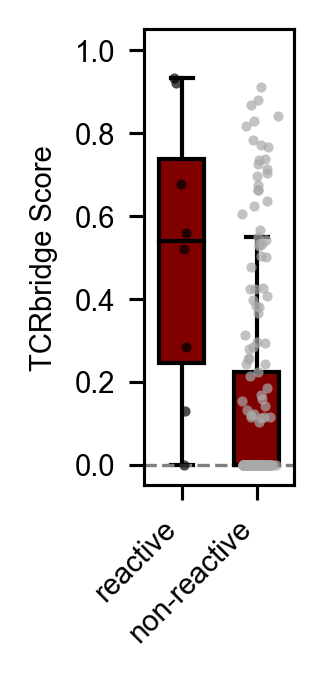

199
197
['180_359', '76_150', '8_11', '9_17', '5_7', '96_188', '40_76', '170_336', '128_252', '44_80', '103_200']
False    186
True      11
Name: hit, dtype: int64
hit
False    0.349367
True     0.631049
Name: tcrbridge, dtype: float64


<Figure size 354.331x708.661 with 0 Axes>

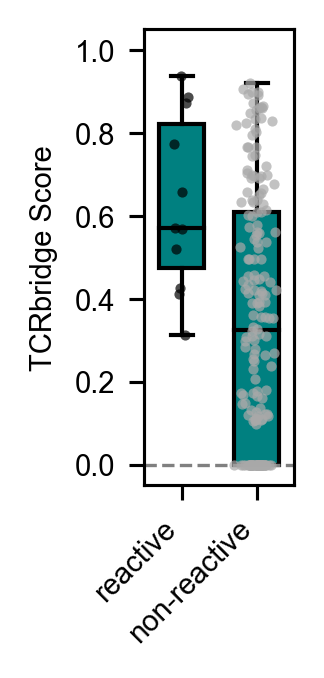

In [ ]:
import matplotlib.patches as mpatches
import numpy as np

df_merged_dict = {}
for epi, df_epi in df_epi_dict.items():
    df_ref_epi = df_ref
    df_merged = pd.merge(df_epi, df_ref_epi, on='Number_in_list', suffixes=('_pred', '_ref'))
    df_merged['order_id_number_only'] = df_merged['Order_ID'].str.removesuffix('_CDR3a+b')
    print(len(df_merged))
    df_merged = df_merged[~df_merged['order_id_number_only'].isin(remove_list)]
    print(len(df_merged))

    df_merged['tcrbridge'] = (df_merged['ABi_score_A_C'] + df_merged['ABi_score_B_C'])/2
    df_merged[f'tcrbridge_{epi}'] = df_merged['tcrbridge']


    df_merged_cp = df_merged.copy()
    if epi == 'SLFSGTMTV'.lower():
        df_merged['hit'] = df_merged['order_id_number_only'].isin(ccser2_list_number_only)
    elif epi == 'AEDVAPQRL'.lower():
        df_merged['hit'] = df_merged['order_id_number_only'].isin(tnfaip2_list_number_only)

    print(df_merged[df_merged['hit']]['order_id_number_only'].tolist())
    print(df_merged['hit'].value_counts())
    print(df_merged.groupby('hit')['tcrbridge'].mean())
    

    import matplotlib.pyplot as plt
    df_merged_dict[epi] = df_merged
    plt.figure(figsize=(3/2.54, 6/2.54)) 
    figsize_boxplot = (3/2.54, 6/2.54)

    data = {
        # 'all': df_merged['tcrbridge'],
        'reactive': df_merged[df_merged['hit']]['tcrbridge'],
        'non-reactive': df_merged[~df_merged['hit']]['tcrbridge'],
    }
    categories = list(data.keys())
    flierprops = dict(marker='.', 
                    markersize=0,
                    linestyle='none'
                    )
    fig, ax = plt.subplots(figsize=(figsize_boxplot[0], figsize_boxplot[1]))
    positions = [1, 2]
    bp = ax.boxplot([data[cat] for cat in categories],
                        sym='.',
                        positions=positions,
                        widths=0.6,
                        patch_artist=True,
                        medianprops=dict(color="black"),
                        flierprops=flierprops
                        )
    for patch in bp['boxes']:
        patch.set_facecolor(name_color_dict[epi.upper()])

    for i, cat in enumerate(categories):
        if cat == "all":


            y_non = df_merged[~df_merged['hit']]['tcrbridge']
            x_non = np.random.normal(positions[i], 0.1, size=len(y_non))
            ax.scatter(
                x_non, y_non,
                alpha=0.7, 
                s=6,
                color=data_colors['non-validating'],
                edgecolors="lightgrey", linewidth=0,
                zorder=3,
                label="non-validating" if i == 0 else ""
            )

            y_val = df_merged[df_merged['hit']]['tcrbridge']
            x_val = np.random.normal(positions[i], 0.1, size=len(y_val))
            ax.scatter(
                x_val, y_val,
                alpha=1, 
                s=6,
                color=data_colors['validating'],
                edgecolors="black", linewidth=0,
                zorder=3,  # ensures dots are above boxplot
                label="validating" if i == 0 else ""
            )
        else:
            y = data[cat]
            x = np.random.normal(positions[i], 0.1, size=len(y))
            ax.scatter(
                x, y,
                alpha=0.7 if cat != 'validating' else 1,
                s=6,
                color=data_colors[cat],
                edgecolors="lightgrey", linewidth=0,
                zorder=3,
                label=cat if i > 0 else ""
            )

    all_positions = positions
    all_labels = categories
    ax.set_xticks(all_positions)
    ax.set_xticklabels(all_labels, rotation=45, ha='right', fontsize=fontsize_axes)  # rotate for clarity if desired
    ax.set_xticks(all_positions)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    patch_AF3 = mpatches.Patch(color=name_color_dict[epi.upper()], label='AF3-ABi')
    ax.set_ylabel("TCRbridge Score", fontsize=fontsize_axes)
    plt.tight_layout()
    plt.savefig(f"{out_path_dropbox}ywe_val-non-val_tcrbridge_boxplot_{epi}.pdf", dpi=300)
    plt.show()
    plt.close()

Epitope: aedvapqrl, AP: 0.344


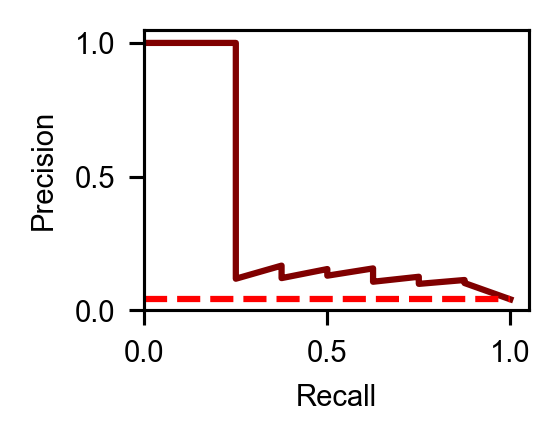

Epitope: slfsgtmtv, AP: 0.226


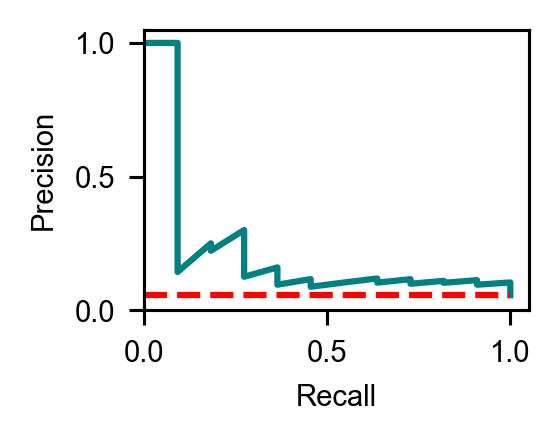

In [11]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

for epi, df_merged in df_merged_dict.items():

    y_true = df_merged['hit'].astype(int).values
    y_score = df_merged['tcrbridge'].values

    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    print(f"Epitope: {epi}, AP: {ap:.3f}")
    plt.figure(figsize=figsize_prc_auc)
    plt.plot(recall, precision, 
            #  linewidth=0.75, 
             color=name_color_dict[epi.upper()])
    plt.xlabel("Recall",fontsize=fontsize_axes)
    plt.ylabel("Precision",fontsize=fontsize_axes)
    # plt.title(f"PR curve ({epi})\nAP={ap:.3f}"
    # plot random line at pos/neg ratio
    positive_ratio = y_true.sum() / len(y_true)
    plt.plot([0, 1], [positive_ratio, positive_ratio], linestyle='--', 
             color='r', 
            #  linewidth=0.75
             )

    plt.ylim(0, 1.05)
    plt.xlim(0, 1.05)
    plt.tight_layout()
    plt.savefig(f"{out_path_dropbox}pr_curve_{epi}_val-non-val.pdf", dpi=300)
    plt.show()
    plt.close()


AUC aedvapqrl: 0.811


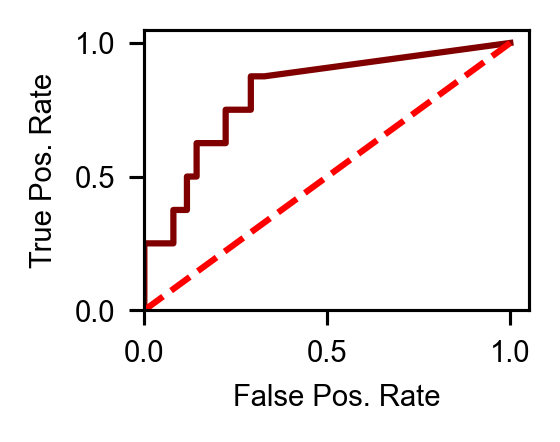

AUC slfsgtmtv: 0.763


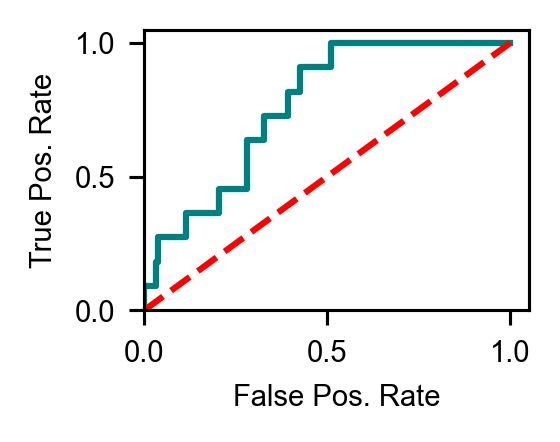

In [12]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

for epi, df_merged in df_merged_dict.items():

    y_true = df_merged['hit'].astype(int).values
    y_score = df_merged['tcrbridge'].values

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    auc_val = roc_auc_score(y_true, y_score)
    print(f"AUC {epi}: {auc_val:.3f}")

    plt.figure(figsize=figsize_prc_auc)
    plt.plot(fpr, tpr, color=name_color_dict[epi.upper()])
    plt.plot([0, 1], [0, 1], linestyle='--', 
            #  linewidth=0.7, 
             color='r')

    plt.xlabel("False Pos. Rate",fontsize=fontsize_axes)
    plt.ylabel("True Pos. Rate",fontsize=fontsize_axes)
    plt.xlim(0, 1.05)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(f"{out_path_dropbox}roc_curve_{epi}_val-non-val.pdf", dpi=300)
    plt.show()
    plt.close()


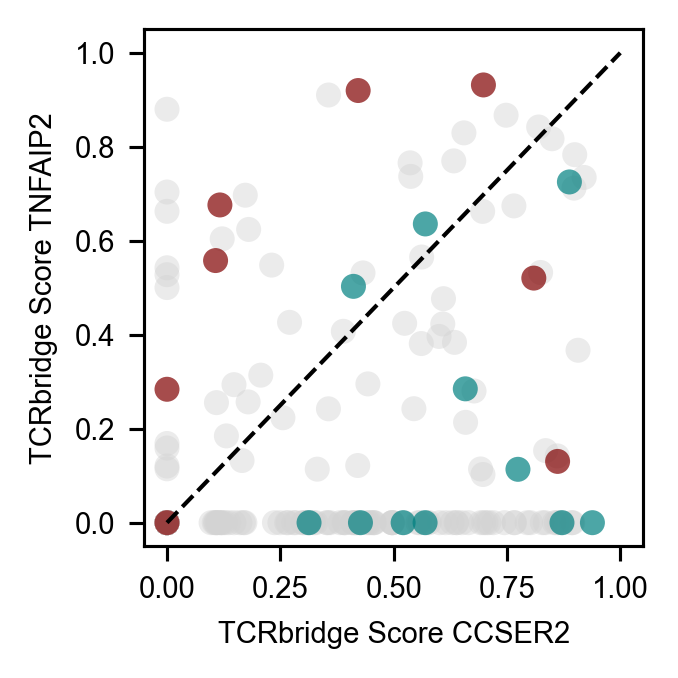

In [9]:
df_merged_cp['ccser2_hit'] = df_merged_cp['order_id_number_only'].isin(ccser2_list_number_only)
df_merged_cp['tnfaip2_hit'] = df_merged_cp['order_id_number_only'].isin(tnfaip2_list_number_only)
df_merged_cp['color'] = df_merged_cp.apply(lambda row: name_color_dict['SLFSGTMTV'] if row['ccser2_hit'] else (name_color_dict['AEDVAPQRL'] if row['tnfaip2_hit'] else 'lightgrey'), axis=1)
df_merged_final = pd.merge(df_merged_dict['slfsgtmtv'][['Number_in_list', 'tcrbridge_slfsgtmtv']], df_merged_dict['aedvapqrl'][['Number_in_list', 'tcrbridge_aedvapqrl']], on='Number_in_list')
df_merged_final = pd.merge(df_merged_final, df_merged_cp[['Number_in_list', 'color']], on='Number_in_list')


fig, ax = plt.subplots(figsize=(6/2.54, 6/2.54))
for color in df_merged_final['color'].unique():
    subset = df_merged_final[df_merged_final['color'] == color]
    alpha =0.45 if color == 'lightgrey' else 0.7
    ax.scatter(subset['tcrbridge_slfsgtmtv'], 
            subset['tcrbridge_aedvapqrl'], 
            c=subset['color'], 
            alpha=alpha,
                edgecolors='black', 
                linewidth=0)
ax.set_xlabel('TCRbridge Score CCSER2', fontsize=fontsize_axes)
ax.set_ylabel('TCRbridge Score TNFAIP2', fontsize=fontsize_axes)
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
patch_ccser2 = mpatches.Patch(color=name_color_dict['SLFSGTMTV'], label='CCSER2 hit')
patch_tnfaip2 = mpatches.Patch(color=name_color_dict['AEDVAPQRL'], label='TNFAIP2 hit')
patch_none = mpatches.Patch(color='lightgrey', label='No hit')

plt.tight_layout()
plt.savefig(out_path_dropbox + 'tcrbridge_scores_ywe_tcrs_scatterplot.pdf', dpi=300,)
plt.show()


In [10]:
df_merged_final['reactive_slsg'] = df_merged_final['Number_in_list'].isin(ccser2_list_number_only)
df_merged_final['reactive_aedv'] = df_merged_final['Number_in_list'].isin(tnfaip2_list_number_only)


SLFSGTMTV
['tcrbridge_slfsgtmtv', 'tcrbridge_aedvapqrl']
[ 0.70710678 -0.70710678]
Average precision score: 0.209, random: 0.056


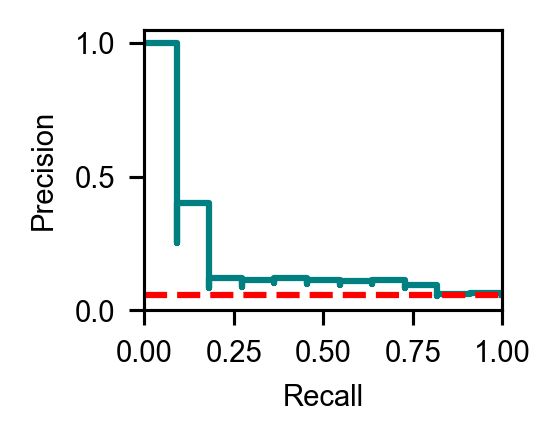

roc_auc 0.677
197
11
197


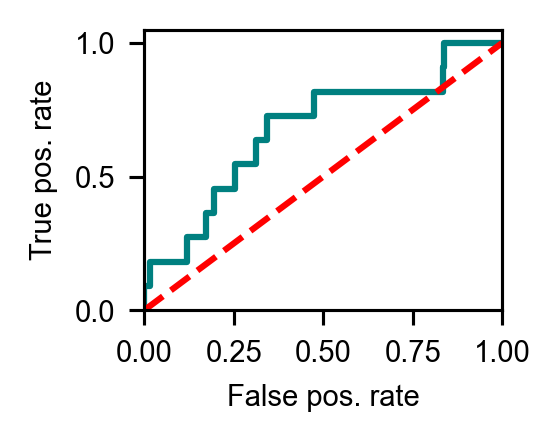


AEDVAPQRL
['tcrbridge_aedvapqrl', 'tcrbridge_slfsgtmtv']
[ 0.70710678 -0.70710678]
Average precision score: 0.183, random: 0.041


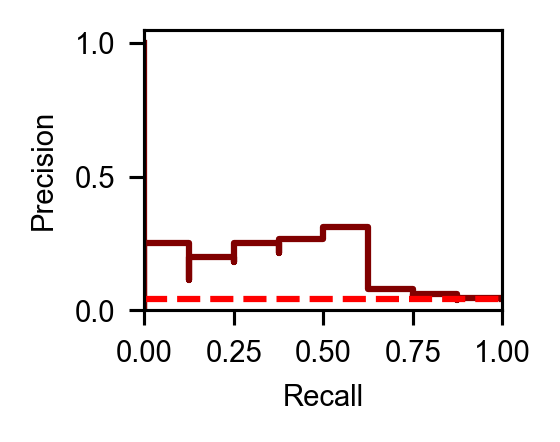

roc_auc 0.750
197
8
197


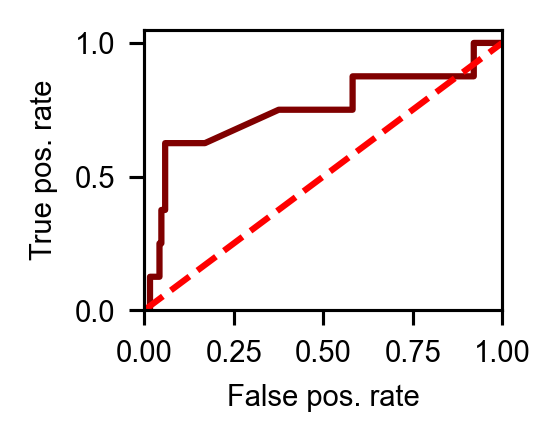

In [11]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score, roc_curve

concatted_all_epitope_preds_with_closeness_orig = df_merged_final.copy()
concatted_all_epitope_preds_with_closeness_orig['cognate_closeness'] = None
n_epitopes = len(all_epitopes)
all_closeness_scores = {}

for epitope in all_epitopes:
    print()
    print(epitope)

    all_score_cols = [f"tcrbridge_{e.lower()}" for e in all_epitopes]
    cols_ordered = [f"tcrbridge_{epitope.lower()}"] + [c for c in all_score_cols if c != f"tcrbridge_{epitope.lower()}"]
    subset_df = concatted_all_epitope_preds_with_closeness_orig.copy()
    points = subset_df[cols_ordered].to_numpy()

    vec = np.zeros(n_epitopes)
    vec[0] = 1
    for v in range(1,n_epitopes):
        vec[v] = -1/(n_epitopes-1)
    vec = vec / np.linalg.norm(vec)

    closeness_all = points @ vec  
    label = [1 if color == name_color_dict[epitope] else 0 for color in subset_df['color']]

    all_closeness_scores[epitope] = {
        'ids': subset_df['Number_in_list'].tolist(),
        'closeness': closeness_all.tolist(),
        'labels': label,
    }

    print(cols_ordered)
    print(vec)

    precision, recall, _ = precision_recall_curve(label, closeness_all)
    average_precision = average_precision_score(label, closeness_all)
    random_performance = sum(label) / len(label)
    print(f'Average precision score: {average_precision:.3f}, random: {random_performance:.3f}')
    plt.figure(figsize=figsize_prc_auc) 
    plt.step(recall, precision, alpha=1, where='post', label=f'AF3-ABi ({average_precision:.2f} AP)', color=name_color_dict[epitope], )
    plt.axhline(y=random_performance, color='r', linestyle='--', label=f'Random ({random_performance:.2f} AP)')
    plt.xlabel('Recall', fontsize=fontsize_axes)
    plt.ylabel('Precision', fontsize=fontsize_axes)
    plt.ylim(0, 1.05)
    plt.xlim(0, 1.0)
    plt.savefig(out_path_dropbox + f'{epitope}-swap_prc_closeness.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    roc_auc = roc_auc_score(label, closeness_all)
    print(f'roc_auc {roc_auc:.3f}')
    print(len(closeness_all))
    print(sum(label))
    print(len(label))
    fpr, tpr, _ = roc_curve(label, closeness_all)
    plt.figure(figsize=figsize_prc_auc)
    plt.plot(fpr, tpr, alpha=1, label=f'AF3-ABi ({roc_auc:.2f} AUC)', color=name_color_dict[epitope])
    plt.plot([0, 1], [0, 1], color='r', linestyle='--', label=f'Random (0.50 AUC)')
    plt.xlabel('False pos. rate', fontsize=fontsize_axes)
    plt.ylabel('True pos. rate', fontsize=fontsize_axes)
    plt.ylim(0, 1.05)
    plt.xlim(0, 1.0)
    plt.savefig(out_path_dropbox + f'{epitope}-swap_auc_closeness.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


11 SLFSGTMTV
8 AEDVAPQRL


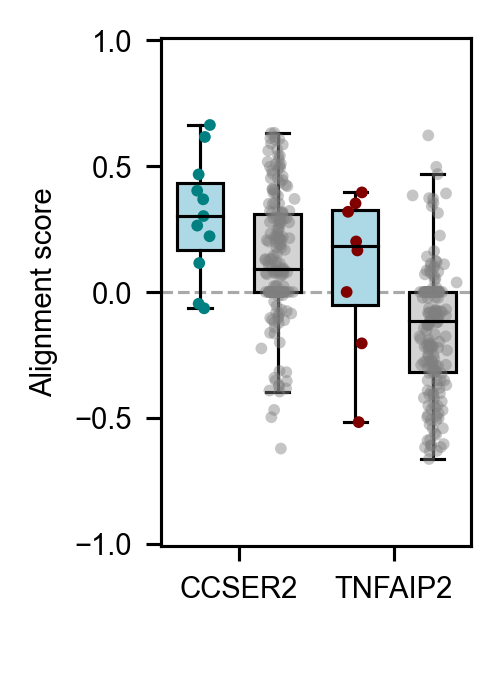

In [12]:
np.random.seed(42)

plt.figure(figsize=(4.5/2.54, 6/2.54)) # 12 x 7
plt.axhline(0, color='darkgrey', linestyle='--', linewidth=mylines)

boxplot_data_validating = []
boxplot_data_nonvalidating = []
all_epitopes_sorted = all_epitopes
all_df_closeness_peptide = {}
for epitope in all_epitopes_sorted:   
    df_closeness_peptide = pd.DataFrame({
    'tcr_id': all_closeness_scores[epitope]['ids'],
    'closeness': all_closeness_scores[epitope]['closeness'],
    'label': all_closeness_scores[epitope]['labels'],
    })

    closeness_scores = df_closeness_peptide['closeness'].tolist()
    labels = df_closeness_peptide['label'].tolist()

    validating_scores = [closeness_scores[i] for i, label in enumerate(labels) if label == 1]
    nonvalidating_scores = [closeness_scores[i] for i, label in enumerate(labels) if label == 0]
    boxplot_data_validating.append(validating_scores)
    boxplot_data_nonvalidating.append(nonvalidating_scores)
    all_df_closeness_peptide[epitope] = df_closeness_peptide
# but dont plot the outliers
positions_validating = np.arange(1, len(all_epitopes_sorted)*2+1, 2)
positions_nonvalidating = np.arange(2, len(all_epitopes_sorted)*2+1, 2)
plt.boxplot(boxplot_data_validating, 
            positions=positions_validating, 
            widths=0.6, 
            patch_artist=True, 
            boxprops=dict(facecolor='lightblue',
                          linewidth=mylines,  
                          ),  
            flierprops=dict(markersize=0,
                            linewidth=mylines, 
                            ),
            medianprops=dict(linewidth=mylines, color='black'),
            capprops=dict(linewidth=mylines),
            whiskerprops=dict(linewidth=mylines),
            ),

plt.boxplot(boxplot_data_nonvalidating, 
            positions=positions_nonvalidating, 
            widths=0.6, 
            patch_artist=True, 
            # mean line is orange but i want it black
            boxprops=dict(facecolor='lightgrey',
                          linewidth=mylines,  
                          ),
            flierprops=dict(markersize=0,
                            linewidth=mylines, 
                            ),
            medianprops=dict(linewidth=mylines, color='black'),
            capprops=dict(linewidth=mylines),
            whiskerprops=dict(linewidth=mylines),
            )

for i, epitope in enumerate(all_epitopes_sorted):   
    df_closeness_peptide = all_df_closeness_peptide[epitope]
    y_validating = [df_closeness_peptide['closeness'][j] for j, label in enumerate(df_closeness_peptide['label']) if label == 1]
    x_validating = np.random.normal(positions_validating[i], 0.08, size=len(y_validating))  # jittered x values
    plt.scatter(x_validating, y_validating, alpha=1, 
                color=name_color_dict[epitope],
                  s=8, 
                  zorder=2,
                edgecolors='none'
                )
    print(len(y_validating), epitope)

    y_nonvalidating = [df_closeness_peptide['closeness'][j] for j, label in enumerate(df_closeness_peptide['label']) if label == 0]
    x_nonvalidating = np.random.normal(positions_nonvalidating[i], 0.08, size=len(y_nonvalidating))  # jittered x values
    plt.scatter(x_nonvalidating, y_nonvalidating, 
                alpha=0.45, 
                color='grey', 
                s=8, 
                zorder=2,
                edgecolors='none'
                )
    
plt.ylabel('Alignment score', fontsize=fontsize_axes)
plt.xticks(positions_validating + 0.5, ['CCSER2', 'TNFAIP2'], rotation=0, ha='center', fontsize=fontsize_axes)
plt.xlabel(' ', fontsize=fontsize_axes)
plt.ylim(-1.01, 1.01)
plt.legend(fontsize=7)
plt.savefig(out_path_dropbox + 'YWE_swap_boxplot-closeness.pdf', dpi=300, bbox_inches='tight')
plt.show()